# 🏆 Predicción del Campeón de la Copa Mundial FIFA 2026
## Proyecto de Ciencia de Datos con Metodología CRISP-DM

| | |
|---|---|
| **Autora** | Karen Chuquimia |
| **Asignatura** | CDA — Ciencia de Datos |
| **Fecha** | Junio 2026 |
| **Dataset** | FIFA World Cup Dataset 1930–2026 (12 archivos CSV) |

---

### Estructura del proyecto (CRISP-DM)

| Fase | Contenido |
|---|---|
| **1. Comprensión del Negocio** | Contexto, objetivos y criterios de éxito |
| **2. Comprensión de los Datos** | Inventario, descripción y calidad de las 12 fuentes |
| **3. Preparación de los Datos** | Limpieza, codificación e ingeniería de variables |
| **4. Análisis Exploratorio (EDA)** | Patrones históricos 1930–2022 y panorama 2026 |
| **5. Construcción del Modelo** | Regresión Poisson + clasificador de campeón + simulación Monte Carlo |
| **6. Evaluación del Modelo** | Backtesting, métricas y validación externa |
| **7. Interpretación y Explicabilidad** | Importancia de variables y perfil del favorito |
| **8. Dashboard Interactivo** | Visualizaciones interactivas con Plotly |


---
# Fase 1 — Comprensión del Negocio

## 1.1 Contexto

La **Copa Mundial FIFA 2026** se disputará del **11 de junio al 19 de julio de 2026** en
**Estados Unidos, Canadá y México**. Es la primera edición con **48 selecciones**
(12 grupos de 4 equipos, 104 partidos en total) y la final se jugará en el MetLife Stadium de Nueva Jersey.
**Argentina** llega como campeona defensora.

Predecir al ganador de un Mundial es un problema clásico de la ciencia de datos deportiva:
casas de apuestas, medios de comunicación y bancos de inversión (Goldman Sachs, UBS) publican
modelos predictivos antes de cada edición. El reto combina datos históricos de casi un siglo
con la información actual de cada selección.

## 1.2 Objetivo del negocio

> **Determinar, mediante un modelo predictivo basado en datos, qué selección tiene la mayor
> probabilidad de ganar la Copa Mundial FIFA 2026, y cuantificar la probabilidad de cada
> uno de los 48 participantes.**

## 1.3 Objetivos de minería de datos

1. **Modelar el resultado de un partido** en función de la diferencia de fuerza (rating ELO)
   entre dos selecciones, usando 117 partidos históricos de mundiales (1930–2022).
2. **Modelar el perfil del campeón** a partir del panel histórico equipo–torneo
   (¿qué características tenían los 22 campeones frente a los demás participantes?).
3. **Simular el torneo 2026 completo** (fase de grupos + eliminatorias) miles de veces
   mediante el método de **Monte Carlo**, para estimar la probabilidad de campeonato de cada equipo.

## 1.4 Criterios de éxito

| Tipo | Criterio |
|---|---|
| **Negocio** | Entregar un ranking de probabilidades de campeonato interpretable y un campeón predicho con su justificación |
| **Técnico (partido)** | El modelo de partido debe superar al azar (50%) y acercarse al baseline "gana el de mayor ELO" en precisión, con buena calibración (log-loss / Brier) |
| **Técnico (campeón)** | En backtesting *leave-one-tournament-out*, el campeón real debe quedar en el **top-3** de probabilidades en la mayoría de las ediciones |
| **Validación externa** | Las probabilidades simuladas deben correlacionar positivamente con el baseline pre-calculado del dataset |

## 1.5 Plan del proyecto

Se sigue el ciclo CRISP-DM completo. Las herramientas: **Python 3.12**, `pandas`, `scikit-learn`,
`matplotlib`/`seaborn` para el EDA y `plotly` para el dashboard interactivo de la Fase 8.


---
# Fase 2 — Comprensión de los Datos

## 2.1 Inventario de fuentes

El dataset cubre **las 22 ediciones del Mundial (1930–2022)** más un **snapshot completo del 2026**:

| # | Archivo | Contenido | Grano |
|---|---|---|---|
| 1 | `wc_tournaments.csv` | Resumen de cada edición: sede, campeón, goles, asistencia | 1 fila por Mundial |
| 2 | `wc_team_appearances.csv` | Panel histórico: etapa alcanzada, W/D/L, goles, ELO | 1 fila por (equipo × edición) |
| 3 | `wc_matches_historical.csv` | Partidos clave (finales, semis, cuartos, etc.) con ELO pre-partido | 1 fila por partido |
| 4 | `wc_team_alltime_stats.csv` | Estadísticas de carrera de cada selección | 1 fila por país |
| 5 | `wc_2026_groups.csv` | Sorteo 2026: 48 equipos en 12 grupos (A–L) | 1 fila por equipo |
| 6 | `wc_2026_teams_snapshot.csv` | Contexto 2026: clasificación, debut, ranking FIFA | 1 fila por equipo |
| 7 | `wc_2026_group_difficulty.csv` | Índice de dificultad del grupo de cada equipo | 1 fila por equipo |
| 8 | `wc_2026_qualifying_summary.csv` | Estadísticas de las eliminatorias rumbo al 2026 | 1 fila por equipo |
| 9 | `wc_coaches_2026.csv` | Entrenadores: experiencia mundialista, estilo | 1 fila por equipo |
| 10 | `wc_head_to_head.csv` | Historial de enfrentamientos directos entre potencias | 1 fila por par de equipos |
| 11 | `wc_top_scorers_by_edition.csv` | Goleadores de cada edición | 1 fila por (jugador × edición) |
| 12 | `wc_prediction_features_2026.csv` | **Matriz de features lista para ML** de los 48 equipos | 1 fila por equipo |

> **Nota sobre el ELO:** el ranking FIFA existe desde 1993; para ediciones anteriores el dataset usa
> el *World Football Elo Rating* (`elo_rating_approx`), un proxy aceptado que se remonta a 1870.


In [1]:
# ============ Librerías y configuración ============
import warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEED = 42
rng = np.random.default_rng(SEED)

# ============ Carga de las 12 fuentes ============
archivos = {
    'torneos'       : 'wc_tournaments.csv',
    'panel'         : 'wc_team_appearances.csv',
    'partidos'      : 'wc_matches_historical.csv',
    'historico'     : 'wc_team_alltime_stats.csv',
    'grupos26'      : 'wc_2026_groups.csv',
    'snapshot26'    : 'wc_2026_teams_snapshot.csv',
    'dificultad26'  : 'wc_2026_group_difficulty.csv',
    'eliminatorias' : 'wc_2026_qualifying_summary.csv',
    'tecnicos26'    : 'wc_coaches_2026.csv',
    'h2h'           : 'wc_head_to_head.csv',
    'goleadores'    : 'wc_top_scorers_by_edition.csv',
    'features26'    : 'wc_prediction_features_2026.csv',
}
data = {k: pd.read_csv(v) for k, v in archivos.items()}

resumen = pd.DataFrame({
    'archivo'  : list(archivos.values()),
    'filas'    : [data[k].shape[0] for k in archivos],
    'columnas' : [data[k].shape[1] for k in archivos],
    'celdas_nulas': [int(data[k].isna().sum().sum()) for k in archivos],
}, index=archivos.keys())
print(f"Se cargaron {len(data)} datasets")
resumen

Se cargaron 12 datasets


,archivo,filas,columnas,celdas_nulas
torneos,wc_tournaments.csv,22,15,0
panel,wc_team_appearances.csv,193,20,477
partidos,wc_matches_historical.csv,117,18,0
historico,wc_team_alltime_stats.csv,43,22,0
grupos26,wc_2026_groups.csv,48,13,0
snapshot26,wc_2026_teams_snapshot.csv,50,11,0
dificultad26,wc_2026_group_difficulty.csv,48,15,0
eliminatorias,wc_2026_qualifying_summary.csv,47,18,50
tecnicos26,wc_coaches_2026.csv,48,13,49
h2h,wc_head_to_head.csv,61,16,7


## 2.2 Exploración inicial de las tablas principales

In [2]:
# Las 22 ediciones del Mundial: una fila por torneo
print('--- wc_tournaments.csv: las 22 ediciones (1930-2022) ---')
data['torneos'][['wc_year','host_nation','total_teams','total_goals',
                 'goals_per_match','champion','runner_up','top_scorer']].head(8)

--- wc_tournaments.csv: las 22 ediciones (1930-2022) ---


,wc_year,host_nation,total_teams,total_goals,goals_per_match,champion,runner_up,top_scorer
0,1930,Uruguay,13,70,3.89,Uruguay,Argentina,Guillermo Stábile
1,1934,Italy,16,70,4.12,Italy,Czechoslovakia,Oldřich Nejedlý
2,1938,France,15,84,4.67,Italy,Hungary,Leônidas
3,1950,Brazil,13,88,4.00,Uruguay,Brazil,Ademir
4,1954,Switzerland,16,140,5.38,West Germany,Hungary,Sándor Kocsis
5,1958,Sweden,16,126,3.60,Brazil,Sweden,Just Fontaine
6,1962,Chile,16,89,2.78,Brazil,Czechoslovakia,Garrincha/Vavá/Sánchez/Ivanov/Albert/Jerkovic
7,1966,England,16,89,2.78,England,West Germany,Eusébio


In [3]:
# Panel histórico equipo x edición: la base del modelo de campeón
print('--- wc_team_appearances.csv ---')
print('Dimensiones:', data['panel'].shape)
print('Estados de participación:', data['panel'].participation_status.value_counts().to_dict())
print('Etapas finales registradas:', data['panel'].final_stage_reached.dropna().unique().tolist())
data['panel'].head(5)

--- wc_team_appearances.csv ---
Dimensiones: (193, 20)
Estados de participación: {'qualified': 191, 'did_not_qualify': 1, 'withdrew': 1}
Etapas finales registradas: ['Winner', 'Runner-up', 'Third place', 'Fourth place', 'Group stage', 'Quarter-finals', 'Round of 16']


,team,confederation,wc_year,participation_status,group_or_pool,final_stage_reached,matches_played,wins,draws,losses,goals_scored,goals_conceded,goal_difference,points_earned,host_nation,wc_titles_before_tournament,consecutive_appearances,elo_rating_approx,fifa_ranking,notes
0,Uruguay,CONMEBOL,1930,qualified,Pool 1,Winner,4.0,4.0,0.0,0.0,15.0,3.0,12.0,8.0,Yes,0,1,1930.0,NaN,First ever WC winner
1,Argentina,CONMEBOL,1930,qualified,Pool 1,Runner-up,4.0,3.0,0.0,1.0,18.0,9.0,9.0,6.0,No,0,1,1900.0,NaN,Lost final 4-2 to Uruguay
2,United States,CONCACAF,1930,qualified,Pool 4,Third place,3.0,2.0,0.0,1.0,7.0,6.0,1.0,4.0,No,0,1,1600.0,NaN,Semi-finalists in first WC
3,Yugoslavia,UEFA,1930,qualified,Pool 2,Fourth place,3.0,2.0,0.0,1.0,7.0,7.0,0.0,4.0,No,0,1,1750.0,NaN,NaN
4,France,UEFA,1930,qualified,Pool 1,Group stage,2.0,1.0,0.0,1.0,4.0,3.0,1.0,2.0,No,0,1,1700.0,NaN,Lost to Argentina; withdrew from Chile match


In [4]:
# Partidos históricos con ELO pre-partido: la base del modelo de partido
print('--- wc_matches_historical.csv ---')
print('Dimensiones:', data['partidos'].shape)
print('Etapas:', data['partidos'].stage.value_counts().to_dict())
print('Tipos de resultado:', data['partidos'].result_type.value_counts().to_dict())
data['partidos'].head(5)

--- wc_matches_historical.csv ---
Dimensiones: (117, 18)
Etapas: {'Semi-final': 35, 'Group Stage': 27, 'Quarter-final': 24, 'Final': 19, 'Round of 16': 8, 'Final Round': 3, 'Third-place': 1}
Tipos de resultado: {'Home Win': 82, 'Away Win': 18, 'Draw': 17}


,match_id,wc_year,stage,date,home_team,away_team,home_goals,away_goals,aet,penalties,home_pen_goals,away_pen_goals,stadium,city,home_pre_match_elo,away_pre_match_elo,winning_team,result_type
0,WC1930_01,1930,Group Stage,1930-07-13,France,Mexico,4,1,No,No,0,0,Estadio Pocitos,Montevideo,1700,1500,France,Home Win
1,WC1930_02,1930,Group Stage,1930-07-13,United States,Belgium,3,0,No,No,0,0,Estadio Pocitos,Montevideo,1600,1680,United States,Home Win
2,WC1930_03,1930,Group Stage,1930-07-15,Yugoslavia,Brazil,2,1,No,No,0,0,Estadio Pocitos,Montevideo,1750,1700,Yugoslavia,Home Win
3,WC1930_04,1930,Group Stage,1930-07-16,Romania,Peru,3,1,No,No,0,0,Estadio Pocitos,Montevideo,1650,1600,Romania,Home Win
4,WC1930_05,1930,Group Stage,1930-07-17,Argentina,France,1,0,No,No,0,0,Estadio Parque Central,Montevideo,1900,1700,Argentina,Home Win


In [5]:
# Matriz de features 2026: los 48 clasificados con sus atributos actuales
print('--- wc_prediction_features_2026.csv ---')
print('Dimensiones:', data['features26'].shape)
print('Equipos por grupo:', data['features26'].groupby('group').size().to_dict())
print('Anfitriones:', data['features26'].loc[data['features26'].host_nation=='Yes','team'].tolist())
print('Debutantes:', data['features26'].loc[data['features26'].is_debut=='Yes','team'].tolist())
data['features26'].head(8)

--- wc_prediction_features_2026.csv ---
Dimensiones: (48, 23)
Equipos por grupo: {'A': 4, 'B': 4, 'C': 4, 'D': 4, 'E': 4, 'F': 4, 'G': 4, 'H': 4, 'I': 4, 'J': 4, 'K': 4, 'L': 4}
Anfitriones: ['Mexico', 'United States', 'Canada']
Debutantes: ['Uzbekistan', 'Jordan', 'Cape Verde', 'Curaçao']


,team,confederation,group,fifa_rank_apr2026,elo_rating_2026,wc_titles,wc_appearances,last_wc_year,best_finish_encoded,squad_avg_age_est,squad_market_value_eur_m,key_player_market_value_eur_m,coach_wc_experience,host_nation,recent_form_pts_last10,qualifying_gf,qualifying_ga,qualifying_pts,consecutive_wc_appearances,titles_before_2026,is_debut,prediction_win_probability_pct,prediction_notes
0,France,UEFA,I,1,1990,2,16,2022.0,7,26.1,1350,300,2,No,24,40,12,46,6,2,No,14.2,Best squad depth; Mbappé peak; coach Deschamps...
1,Spain,UEFA,H,2,1990,1,16,2022.0,7,25.8,1200,180,1,No,22,43,10,48,8,1,No,12.8,Yamal/Pedri generational; dominant possession;...
2,Argentina,CONMEBOL,J,3,1980,3,18,2022.0,7,28.4,1080,150,0,No,20,30,18,38,5,3,No,11.5,Defending champions; Messi 37yr last dance; te...
3,England,UEFA,L,4,1940,1,16,2022.0,6,25.9,1300,200,0,No,21,35,9,45,8,1,No,10.8,Bellingham best player in world; Saka/Foden/Pa...
4,Portugal,UEFA,K,5,1940,0,8,2022.0,5,27.3,1050,180,1,No,20,32,11,40,4,0,No,7.4,Post-Ronaldo transition risk; Félix/Fernandes ...
5,Brazil,CONMEBOL,C,6,2030,5,22,2022.0,7,25.6,1100,220,0,No,18,28,15,36,22,5,No,9.2,Vinicius/Rodrygo elite; 24yr drought; historic...
6,Netherlands,UEFA,F,7,1940,0,11,2022.0,4,26.8,980,120,1,No,22,31,10,40,8,0,No,6.8,Van Dijk world class; Gakpo/Depay; semi-final ...
7,Morocco,CAF,C,8,1860,0,6,2022.0,5,26.2,420,70,1,No,19,22,8,34,3,0,No,4.2,2022 semis showed world-class; Regragui tactic...


## 2.3 Calidad de los datos

In [6]:
# Diagnóstico de valores nulos en las tablas que alimentan el modelo
print('Nulos en el PANEL histórico:')
nulos_panel = data['panel'].isna().sum()
print(nulos_panel[nulos_panel > 0].to_string())
print()
print('Nulos en PARTIDOS históricos:', int(data['partidos'].isna().sum().sum()))
print('Nulos en FEATURES 2026:')
nulos_f = data['features26'].isna().sum()
print(nulos_f[nulos_f > 0].to_string() if nulos_f.sum() else '  (ninguno en columnas numéricas clave)')
print()
print('Duplicados panel:', data['panel'].duplicated(subset=['team','wc_year']).sum())
print('Duplicados features 2026:', data['features26'].duplicated(subset=['team']).sum())

Nulos en el PANEL histórico:
group_or_pool          180
final_stage_reached      2
matches_played           2
wins                     2
draws                    2
losses                   2
goals_scored             2
goals_conceded           2
goal_difference          2
points_earned            2
host_nation              2
elo_rating_approx        2
fifa_ranking           193
notes                   82

Nulos en PARTIDOS históricos: 0
Nulos en FEATURES 2026:
last_wc_year    4

Duplicados panel: 0
Duplicados features 2026: 0


**Hallazgos de calidad:**

- La columna `fifa_ranking` del panel histórico está **100% vacía** (el ranking FIFA nace en 1993) → se descarta y se usa `elo_rating_approx` como medida de fuerza, disponible para *todas* las ediciones.
- Los nulos de `final_stage_reached` corresponden a filas con `participation_status` distinto de `qualified` (equipos que no clasificaron o se retiraron) → se filtran en la Fase 3.
- Los 117 partidos históricos tienen **ELO pre-partido completo** para ambos equipos: ideal para entrenar el modelo de partido.
- La matriz 2026 está completa para las variables numéricas del modelo; los pocos nulos están en columnas de texto descriptivo.
- No hay duplicados en las llaves naturales (`team`, `wc_year`).


---
# Fase 3 — Preparación de los Datos

Se construyen **tres datasets analíticos**:

1. **`panel`** — histórico equipo×edición limpio, con la etapa codificada ordinalmente, la marca de campeón (variable objetivo) y el ELO estandarizado *dentro de cada edición* (la fuerza es relativa a los rivales de ese año).
2. **`goles_largo`** — partidos históricos en formato largo (2 filas por partido) para ajustar la regresión Poisson de goles.
3. **`f26`** — tabla maestra de los 48 equipos del 2026 con un **ELO ajustado** que incorpora la ventaja del anfitrión y la forma reciente.


In [7]:
# ============ 3.1 Panel histórico limpio ============
panel = data['panel'].copy()

# Solo equipos que realmente jugaron el Mundial
panel = panel[panel.participation_status == 'qualified'].copy()

# Codificación ordinal de la etapa alcanzada (1 = fase de grupos ... 7 = campeón)
orden_etapas = {'Group stage': 1, 'Round of 16': 2, 'Quarter-finals': 3,
                'Fourth place': 4, 'Third place': 5, 'Runner-up': 6, 'Winner': 7}
panel['etapa_num']    = panel.final_stage_reached.map(orden_etapas)
panel['es_campeon']   = (panel.final_stage_reached == 'Winner').astype(int)
panel['es_anfitrion'] = (panel.host_nation == 'Yes').astype(int)

# fifa_ranking esta 100% vacío -> fuera
panel = panel.drop(columns=['fifa_ranking'])

# ELO estandarizado DENTRO de cada edición: mide fuerza relativa a los rivales de ese año
panel['elo_z'] = panel.groupby('wc_year')['elo_rating_approx'] \
                      .transform(lambda s: (s - s.mean()) / s.std())

print('Panel limpio:', panel.shape)
print('Campeones en el panel:', panel.es_campeon.sum(), '(uno por cada una de las 22 ediciones)')
assert panel.es_campeon.sum() == 22, 'Debe haber exactamente 22 campeones'
assert panel.etapa_num.isna().sum() == 0, 'Toda fila qualified debe tener etapa'
panel[['team','wc_year','final_stage_reached','etapa_num','es_campeon',
       'es_anfitrion','elo_rating_approx','elo_z','wc_titles_before_tournament',
       'consecutive_appearances']].head(6)

Panel limpio: (191, 23)
Campeones en el panel: 22 (uno por cada una de las 22 ediciones)


,team,wc_year,final_stage_reached,etapa_num,es_campeon,es_anfitrion,elo_rating_approx,elo_z,wc_titles_before_tournament,consecutive_appearances
0,Uruguay,1930,Winner,7,1,1,1930.0,1.911252,0,1
1,Argentina,1930,Runner-up,6,0,0,1900.0,1.695822,0,1
2,United States,1930,Third place,5,0,0,1600.0,-0.458480,0,1
3,Yugoslavia,1930,Fourth place,4,0,0,1750.0,0.618671,0,1
4,France,1930,Group stage,1,0,0,1700.0,0.259621,0,1
5,Brazil,1930,Group stage,1,0,0,1700.0,0.259621,0,1


In [8]:
# ============ 3.2 Dataset de partidos para el modelo Poisson ============
mh = data['partidos'].copy()
mh['diff_elo'] = mh.home_pre_match_elo - mh.away_pre_match_elo

# Formato largo: cada partido aporta 2 observaciones (goles de cada equipo
# en función de SU diferencia de ELO contra el rival)
goles_largo = pd.concat([
    pd.DataFrame({'goles': mh.home_goals, 'diff_elo': mh.diff_elo,  'wc_year': mh.wc_year}),
    pd.DataFrame({'goles': mh.away_goals, 'diff_elo': -mh.diff_elo, 'wc_year': mh.wc_year}),
], ignore_index=True)

# Flag binario para el modelo logístico de victoria (se excluyen empates)
mh['gana_local'] = (mh.result_type == 'Home Win').astype(int)

print('Observaciones equipo-partido para Poisson:', goles_largo.shape[0])
print('Partidos sin empate para el modelo logístico:',
      (mh.result_type != 'Draw').sum(), 'de', len(mh))
goles_largo.head()

Observaciones equipo-partido para Poisson: 234
Partidos sin empate para el modelo logístico: 100 de 117


,goles,diff_elo,wc_year
0,4,200,1930
1,3,-80,1930
2,2,50,1930
3,3,50,1930
4,1,200,1930


In [9]:
# ============ 3.3 Tabla maestra 2026 con ELO ajustado ============
f26 = data['features26'].copy()
f26['anfitrion'] = (f26.host_nation == 'Yes').astype(int)
f26['debut']     = (f26.is_debut == 'Yes').astype(int)

# Ajustes de fuerza (justificación empírica en la Fase 4):
#   - BONO_ANFITRION: los anfitriones sobre-rinden históricamente (~+50 pts ELO, conservador
#     frente a los +100 del ELO clásico porque la sede 2026 está repartida en 3 países)
#   - PESO_FORMA: convierte la forma reciente (pts en últimos 10 partidos) en puntos ELO
BONO_ANFITRION = 50
PESO_FORMA     = 4

forma_mediana = f26.recent_form_pts_last10.median()
f26['elo_ajustado'] = (f26.elo_rating_2026
                       + BONO_ANFITRION * f26.anfitrion
                       + PESO_FORMA * (f26.recent_form_pts_last10 - forma_mediana))

# ELO estandarizado dentro del torneo 2026 (mismo criterio que el panel histórico)
f26['elo_z'] = (f26.elo_rating_2026 - f26.elo_rating_2026.mean()) / f26.elo_rating_2026.std()

print('Tabla maestra 2026:', f26.shape)
print('Nulos en columnas del modelo:',
      int(f26[['elo_ajustado','elo_z','titles_before_2026',
               'consecutive_wc_appearances','anfitrion']].isna().sum().sum()))
f26[['team','group','fifa_rank_apr2026','elo_rating_2026','recent_form_pts_last10',
     'anfitrion','elo_ajustado','elo_z']].sort_values('elo_ajustado', ascending=False).head(10)

Tabla maestra 2026: (48, 27)
Nulos en columnas del modelo: 0


,team,group,fifa_rank_apr2026,elo_rating_2026,recent_form_pts_last10,anfitrion,elo_ajustado,elo_z
5,Brazil,C,6,2030,18,0,2034.0,1.971555
0,France,I,1,1990,24,0,2018.0,1.683474
1,Spain,H,2,1990,22,0,2010.0,1.683474
2,Argentina,J,3,1980,20,0,1992.0,1.611454
9,Germany,E,10,1960,18,0,1964.0,1.467413
6,Netherlands,F,7,1940,22,0,1960.0,1.323373
3,England,L,4,1940,21,0,1956.0,1.323373
4,Portugal,K,5,1940,20,0,1952.0,1.323373
8,Belgium,G,9,1900,20,0,1912.0,1.035292
15,Uruguay,H,17,1890,19,0,1898.0,0.963271


**Decisiones de preparación (resumen):**

| Decisión | Justificación |
|---|---|
| Filtrar `participation_status == 'qualified'` | Solo interesa el rendimiento de quienes jugaron el torneo |
| Eliminar `fifa_ranking` | 100% nula; `elo_rating_approx` cubre todas las ediciones |
| `etapa_num` ordinal 1–7 | Permite analizar la progresión como variable numérica |
| `elo_z` por edición | La fuerza es **relativa**: un ELO de 1900 en 1950 no equivale a 1900 en 2022 |
| Formato largo de goles | La regresión Poisson modela los goles de *cada equipo* según su ventaja de ELO |
| `elo_ajustado` 2026 | Integra anfitrión y forma reciente en una sola medida de fuerza para la simulación |


---
# Fase 4 — Análisis Exploratorio de Datos (EDA)

Se exploran los patrones históricos que sustentan el modelo: evolución del juego,
palmarés, dominio por confederación, ventaja del anfitrión y —lo más importante—
la **capacidad del ELO para explicar resultados y etapas alcanzadas**.


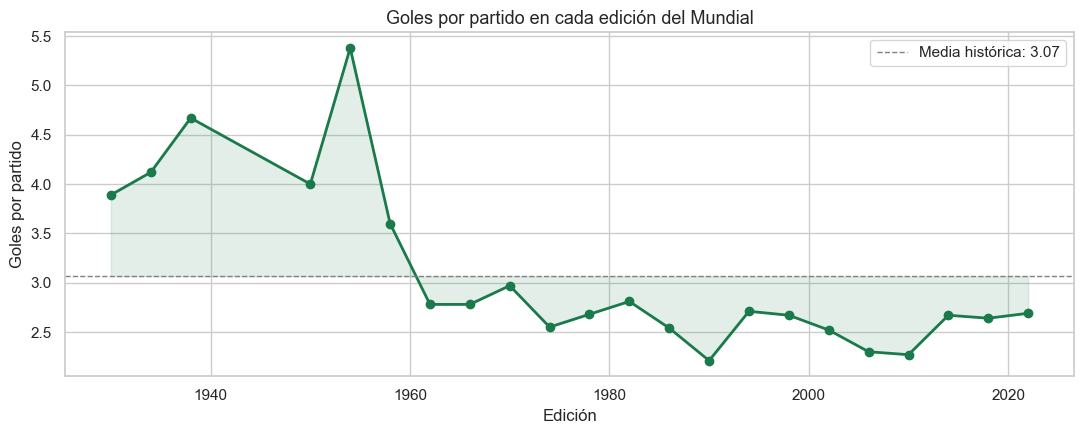

Máximo histórico: 1954 (5.38 goles/partido)
Mínimo histórico: 1990 (2.21 goles/partido)
Últimas 5 ediciones: 2.51 goles/partido


In [10]:
# ============ 4.1 Evolución de los goles por partido (1930-2022) ============
t = data['torneos']
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t.wc_year, t.goals_per_match, marker='o', lw=2, color='#1a7a4a')
ax.axhline(t.goals_per_match.mean(), color='gray', ls='--', lw=1,
           label=f'Media histórica: {t.goals_per_match.mean():.2f}')
ax.fill_between(t.wc_year, t.goals_per_match, t.goals_per_match.mean(),
                alpha=.12, color='#1a7a4a')
ax.set(title='Goles por partido en cada edición del Mundial',
       xlabel='Edición', ylabel='Goles por partido')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Máximo histórico: {t.loc[t.goals_per_match.idxmax(),'wc_year']} "
      f"({t.goals_per_match.max():.2f} goles/partido)")
print(f"Mínimo histórico: {t.loc[t.goals_per_match.idxmin(),'wc_year']} "
      f"({t.goals_per_match.min():.2f} goles/partido)")
print(f"Últimas 5 ediciones: {t.tail(5).goals_per_match.mean():.2f} goles/partido")

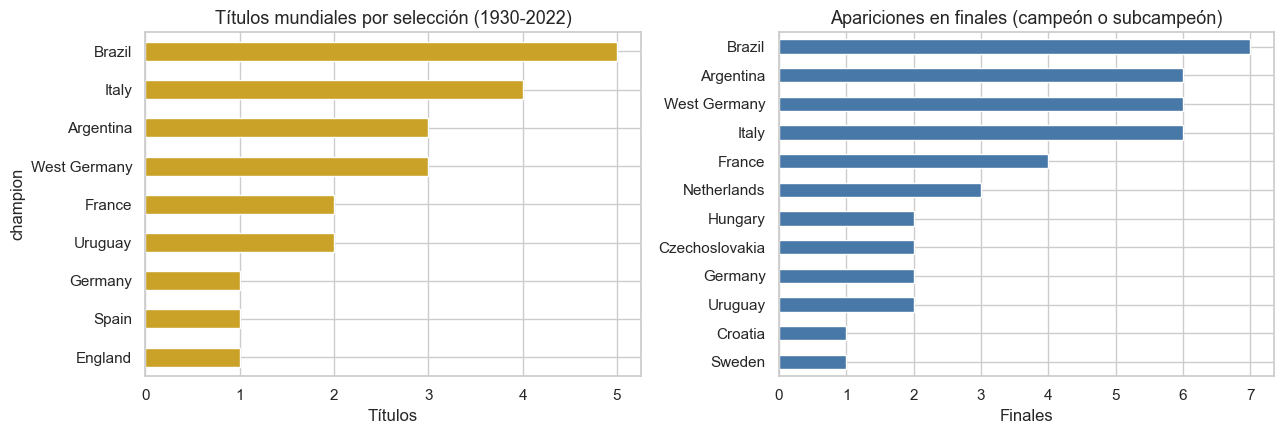

Solo 9 países han ganado el Mundial en 92 años:
Brazil (5), Italy (4), West Germany (3), Argentina (3), Uruguay (2), France (2), England (1), Spain (1), Germany (1)


In [11]:
# ============ 4.2 Palmarés histórico: ¿quién ha ganado mundiales? ============
campeones = data['torneos'].champion.value_counts()
finalistas = pd.concat([data['torneos'].champion,
                        data['torneos'].runner_up]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
campeones.sort_values().plot.barh(ax=axes[0], color='#c9a227')
axes[0].set(title='Títulos mundiales por selección (1930-2022)', xlabel='Títulos')
finalistas.sort_values().tail(12).plot.barh(ax=axes[1], color='#4878a8')
axes[1].set(title='Apariciones en finales (campeón o subcampeón)', xlabel='Finales')
plt.tight_layout(); plt.show()

print('Solo', campeones.shape[0], 'países han ganado el Mundial en 92 años:')
print(', '.join(f'{p} ({n})' for p, n in campeones.items()))

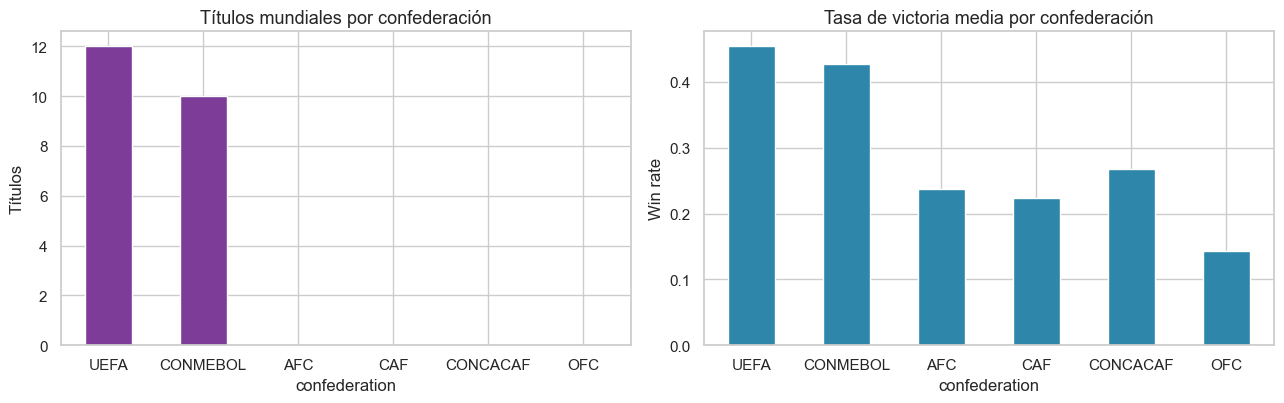

,titulos,finales,win_rate_medio,paises
confederation,,,,
UEFA,12,29,0.454050,20
CONMEBOL,10,15,0.427375,8
AFC,0,0,0.237600,5
CAF,0,0,0.223714,7
CONCACAF,0,0,0.267500,2
OFC,0,0,0.143000,1


In [12]:
# ============ 4.3 Dominio por confederación ============
hist = data['historico']
conf = hist.groupby('confederation').agg(
    titulos=('titles', 'sum'),
    finales=('finals_reached', 'sum'),
    win_rate_medio=('win_rate', 'mean'),
    paises=('team', 'count')).sort_values('titulos', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
conf.titulos.plot.bar(ax=axes[0], color='#7d3c98', rot=0)
axes[0].set(title='Títulos mundiales por confederación', ylabel='Títulos')
conf.win_rate_medio.plot.bar(ax=axes[1], color='#2e86ab', rot=0)
axes[1].set(title='Tasa de victoria media por confederación', ylabel='Win rate')
plt.tight_layout(); plt.show()
conf

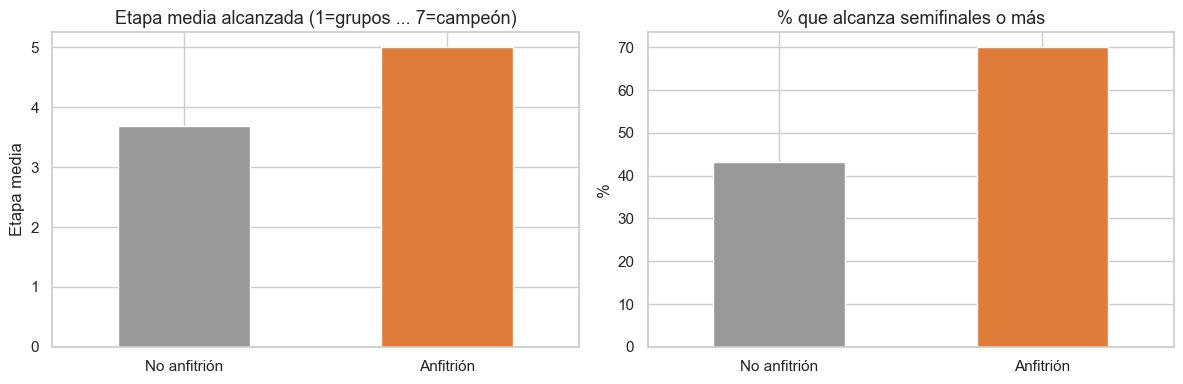

              equipos  etapa_media  pct_semifinal  pct_campeon
No anfitrión      171         3.68          43.27         9.36
Anfitrión          20         5.00          70.00        30.00

Anfitriones campeones: Uruguay 1930, Italy 1934, England 1966, West Germany 1974, Argentina 1978, France 1998
=> La ventaja del anfitrión es real: justifica el BONO_ANFITRION de la Fase 3.


In [13]:
# ============ 4.4 ¿Existe la ventaja del anfitrión? ============
adv = panel.groupby('es_anfitrion').agg(
    equipos=('team', 'count'),
    etapa_media=('etapa_num', 'mean'),
    pct_semifinal=('etapa_num', lambda s: 100 * (s >= 4).mean()),
    pct_campeon=('es_campeon', lambda s: 100 * s.mean()))
adv.index = ['No anfitrión', 'Anfitrión']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adv.etapa_media.plot.bar(ax=axes[0], color=['#999999', '#e07b39'], rot=0)
axes[0].set(title='Etapa media alcanzada (1=grupos ... 7=campeón)', ylabel='Etapa media')
adv.pct_semifinal.plot.bar(ax=axes[1], color=['#999999', '#e07b39'], rot=0)
axes[1].set(title='% que alcanza semifinales o más', ylabel='%')
plt.tight_layout(); plt.show()

print(adv.round(2).to_string())
print()
hosts_campeones = panel[(panel.es_anfitrion==1) & (panel.es_campeon==1)][['team','wc_year']]
print('Anfitriones campeones:', ', '.join(f"{r.team} {r.wc_year}" for r in hosts_campeones.itertuples()))
print('=> La ventaja del anfitrión es real: justifica el BONO_ANFITRION de la Fase 3.')

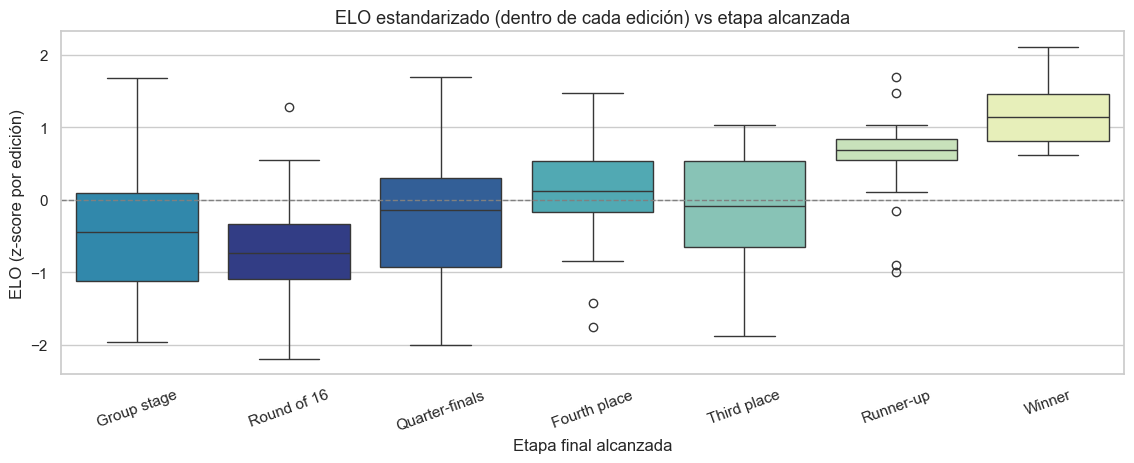

Correlación elo_z vs etapa alcanzada: 0.526
ELO-z medio de los campeones: 1.16
ELO-z medio del resto:        -0.15


In [14]:
# ============ 4.5 ¿El ELO explica la etapa alcanzada? ============
orden_lbl = ['Group stage','Round of 16','Quarter-finals','Fourth place',
             'Third place','Runner-up','Winner']
fig, ax = plt.subplots(figsize=(11.5, 4.8))
sns.boxplot(data=panel, x='final_stage_reached', y='elo_z', order=orden_lbl,
            hue='final_stage_reached', palette='YlGnBu', legend=False, ax=ax)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set(title='ELO estandarizado (dentro de cada edición) vs etapa alcanzada',
       xlabel='Etapa final alcanzada', ylabel='ELO (z-score por edición)')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

corr = panel[['elo_z','etapa_num']].corr().iloc[0, 1]
print(f'Correlación elo_z vs etapa alcanzada: {corr:.3f}')
print(f"ELO-z medio de los campeones: {panel.loc[panel.es_campeon==1,'elo_z'].mean():.2f}")
print(f"ELO-z medio del resto:        {panel.loc[panel.es_campeon==0,'elo_z'].mean():.2f}")

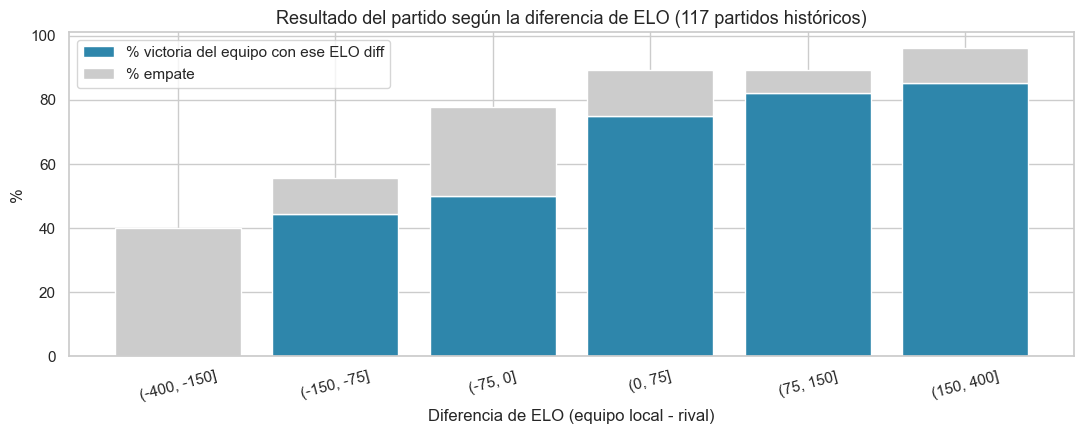

,partidos,pct_gana_local,pct_empate
diff_elo,,,
"(-400, -150]",5,0.000,0.400
"(-150, -75]",9,0.444,0.111
"(-75, 0]",18,0.500,0.278
"(0, 75]",28,0.750,0.143
"(75, 150]",28,0.821,0.071
"(150, 400]",27,0.852,0.111


In [15]:
# ============ 4.6 Diferencia de ELO y resultado del partido ============
bins = pd.cut(mh.diff_elo, [-400, -150, -75, 0, 75, 150, 400])
winrate = mh.groupby(bins, observed=True).agg(
    partidos=('gana_local', 'count'),
    pct_gana_local=('gana_local', 'mean'),
    pct_empate=('result_type', lambda s: (s == 'Draw').mean()))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = range(len(winrate))
ax.bar(x, 100*winrate.pct_gana_local, color='#2e86ab', label='% victoria del equipo con ese ELO diff')
ax.bar(x, 100*winrate.pct_empate, bottom=100*winrate.pct_gana_local,
       color='#cccccc', label='% empate')
ax.set_xticks(x); ax.set_xticklabels([str(i) for i in winrate.index], rotation=15)
ax.set(title='Resultado del partido según la diferencia de ELO (117 partidos históricos)',
       xlabel='Diferencia de ELO (equipo local - rival)', ylabel='%')
ax.legend(); plt.tight_layout(); plt.show()
winrate.round(3)

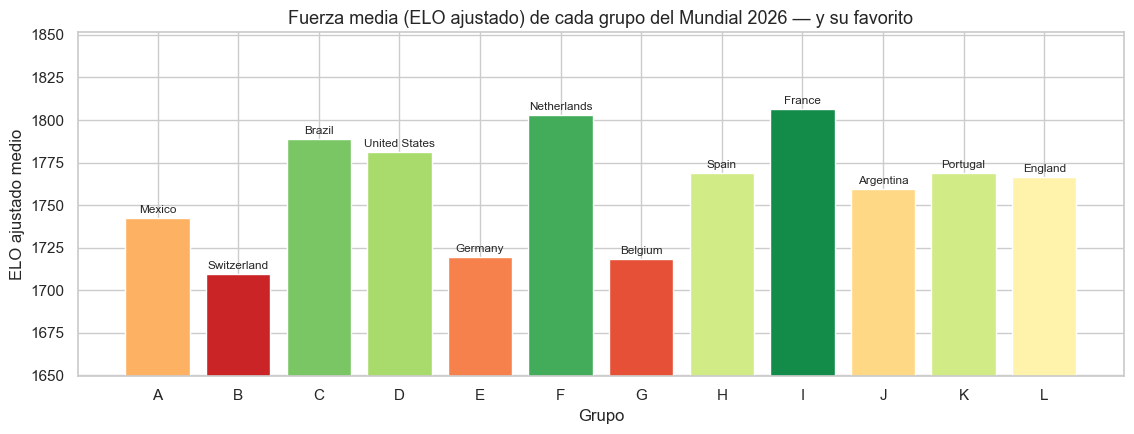

Los 10 equipos más fuertes del 2026 (ELO ajustado):
       team group  elo_rating_2026  recent_form_pts_last10  anfitrion  elo_ajustado
     Brazil     C             2030                      18          0        2034.0
     France     I             1990                      24          0        2018.0
      Spain     H             1990                      22          0        2010.0
  Argentina     J             1980                      20          0        1992.0
    Germany     E             1960                      18          0        1964.0
Netherlands     F             1940                      22          0        1960.0
    England     L             1940                      21          0        1956.0
   Portugal     K             1940                      20          0        1952.0
    Belgium     G             1900                      20          0        1912.0
    Uruguay     H             1890                      19          0        1898.0


In [16]:
# ============ 4.7 Panorama 2026: fuerza y dificultad por grupo ============
fza_grupo = f26.groupby('group').agg(elo_medio=('elo_ajustado', 'mean'),
                                     elo_max=('elo_ajustado', 'max'))
top_grupo = f26.loc[f26.groupby('group').elo_ajustado.idxmax(), ['group','team']] \
              .set_index('group').team

fig, ax = plt.subplots(figsize=(11.5, 4.5))
colores = sns.color_palette('RdYlGn_r', len(fza_grupo))
rank_colores = fza_grupo.elo_medio.rank(ascending=False).astype(int) - 1
ax.bar(fza_grupo.index, fza_grupo.elo_medio,
       color=[colores[i] for i in rank_colores])
for g, v in fza_grupo.elo_medio.items():
    ax.text(g, v + 3, top_grupo[g], ha='center', fontsize=8.5, rotation=0)
ax.set_ylim(fza_grupo.elo_medio.min() - 60, fza_grupo.elo_medio.max() + 45)
ax.set(title='Fuerza media (ELO ajustado) de cada grupo del Mundial 2026 — y su favorito',
       xlabel='Grupo', ylabel='ELO ajustado medio')
plt.tight_layout(); plt.show()

print('Los 10 equipos más fuertes del 2026 (ELO ajustado):')
print(f26.nlargest(10, 'elo_ajustado')[['team','group','elo_rating_2026',
      'recent_form_pts_last10','anfitrion','elo_ajustado']].to_string(index=False))

## Hallazgos del EDA

1. **El fútbol se volvió más defensivo**: de ~4 goles/partido en los años 30 a ~2.6 en la era moderna → el modelo de goles debe calibrarse con la relación goles–ELO, no con promedios antiguos.
2. **Ganar el Mundial es un club exclusivo**: solo 8 países lo han logrado; la experiencia previa (títulos, apariciones consecutivas) es un rasgo distintivo del campeón → se incluye en el modelo de campeón.
3. **UEFA y CONMEBOL concentran todos los títulos** de la historia.
4. **La ventaja del anfitrión es real**: los anfitriones alcanzan etapas claramente superiores y varios fueron campeones (Uruguay 1930, Italia 1934, Inglaterra 1966, Alemania 1974, Argentina 1978, Francia 1998) → justifica el `BONO_ANFITRION`.
5. **El ELO discrimina muy bien**: la correlación con la etapa alcanzada es fuerte y la probabilidad de victoria crece monotónicamente con la diferencia de ELO → es la columna vertebral correcta para el modelo de partido.
6. **2026**: los grupos no son homogéneos; hay grupos "de la muerte" y grupos accesibles, lo que la simulación Monte Carlo captura de forma natural.


---
# Fase 5 — Construcción del Modelo Predictivo

## Arquitectura: tres componentes complementarios

```
        ┌──────────────────────────┐   ┌──────────────────────────────┐
        │ (A) MODELO DE PARTIDO    │   │ (B) MODELO DE CAMPEÓN        │
        │ Regresión Poisson:       │   │ Reg. Logística + Random      │
        │ goles ~ diferencia ELO   │   │ Forest sobre panel histórico │
        │ (117 partidos 1930-2022) │   │ (perfil de los 22 campeones) │
        └────────────┬─────────────┘   └──────────────┬───────────────┘
                     │                                │
                     ▼                                │
        ┌──────────────────────────┐                  │
        │ (C) SIMULACIÓN           │                  │
        │ MONTE CARLO              │                  │
        │ 10,000 torneos completos │                  │
        │ grupos → R32 → ... final │                  │
        └────────────┬─────────────┘                  │
                     │                                │
                     ▼                                ▼
              ┌────────────────────────────────────────────┐
              │   PROBABILIDAD FINAL DE CAMPEONATO          │
              │   ensamble: 60% simulación + 40% modelo B   │
              └────────────────────────────────────────────┘
```

- **(A)** convierte la diferencia de ELO en goles esperados → permite simular cualquier marcador, incluidos empates (clave en fase de grupos).
- **(B)** aprende del histórico **qué perfil tiene un campeón** (fuerza relativa, pedigrí, anfitrión, regularidad).
- **(C)** juega el torneo 2026 completo miles de veces con el formato real de 48 equipos: 12 grupos de 4 → avanzan los 2 primeros + los 8 mejores terceros → eliminatorias desde 16avos (R32) hasta la final.


Modelo: goles_esperados = exp(0.3750 + 0.3274 x diff_elo/100)

Goles esperados según la ventaja de ELO:
  diff ELO -200  ->  0.76 goles esperados
  diff ELO -100  ->  1.05 goles esperados
  diff ELO   +0  ->  1.45 goles esperados
  diff ELO +100  ->  2.02 goles esperados
  diff ELO +200  ->  2.80 goles esperados


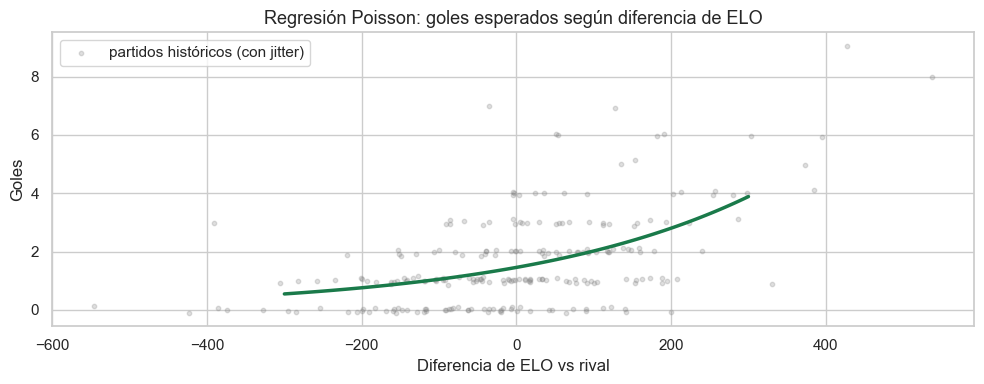

In [17]:
# ============ 5.1 (A) Modelo de partido: regresión Poisson de goles ============
from sklearn.linear_model import PoissonRegressor

X_pois = goles_largo[['diff_elo']] / 100.0   # escala: bloques de 100 pts ELO
y_pois = goles_largo['goles']
modelo_poisson = PoissonRegressor(alpha=1e-6, max_iter=1000).fit(X_pois, y_pois)
B0, B1 = modelo_poisson.intercept_, modelo_poisson.coef_[0]

print(f'Modelo: goles_esperados = exp({B0:.4f} + {B1:.4f} x diff_elo/100)')
print()
print('Goles esperados según la ventaja de ELO:')
for d in [-200, -100, 0, 100, 200]:
    lam = math.exp(B0 + B1 * d / 100)
    print(f'  diff ELO {d:+4d}  ->  {lam:.2f} goles esperados')

# Curva visual
dd = np.linspace(-300, 300, 100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dd, np.exp(B0 + B1 * dd / 100), lw=2.5, color='#1a7a4a')
ax.scatter(goles_largo.diff_elo + rng.normal(0, 6, len(goles_largo)),
           goles_largo.goles + rng.normal(0, .06, len(goles_largo)),
           s=10, alpha=.25, color='gray', label='partidos históricos (con jitter)')
ax.set(title='Regresión Poisson: goles esperados según diferencia de ELO',
       xlabel='Diferencia de ELO vs rival', ylabel='Goles')
ax.legend(); plt.tight_layout(); plt.show()

In [18]:
# ============ 5.2 (A') Modelo logístico de victoria (apoyo: penales y evaluación) ============
from sklearn.linear_model import LogisticRegression

sin_empate = mh[mh.result_type != 'Draw'].copy()
X_log = sin_empate[['diff_elo']] / 100.0
y_log = sin_empate['gana_local']
modelo_logit_partido = LogisticRegression(max_iter=1000).fit(X_log, y_log)
G0 = modelo_logit_partido.intercept_[0]
G1 = modelo_logit_partido.coef_[0][0]

print(f'P(victoria) = sigmoide({G0:.3f} + {G1:.3f} x diff_elo/100)')
for d in [0, 50, 100, 200]:
    p = 1 / (1 + math.exp(-(G0 + G1 * d / 100)))
    print(f'  diff ELO {d:+4d} -> P(victoria) = {p:.1%}')

def prob_victoria_elo(diff_elo, suavizado=1.0):
    # Probabilidad de victoria del equipo A; 'suavizado' < 1 comprime hacia 50%
    # (se usa para penales, donde el azar pesa más)
    return 1 / (1 + math.exp(-suavizado * (G0 + G1 * diff_elo / 100)))

P(victoria) = sigmoide(1.047 + 1.097 x diff_elo/100)
  diff ELO   +0 -> P(victoria) = 74.0%
  diff ELO  +50 -> P(victoria) = 83.1%
  diff ELO +100 -> P(victoria) = 89.5%
  diff ELO +200 -> P(victoria) = 96.2%


In [19]:
# ============ 5.3 (B) Modelo de campeón sobre el panel histórico ============
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FEATS = ['elo_z', 'wc_titles_before_tournament', 'consecutive_appearances', 'es_anfitrion']
X_camp = panel[FEATS]
y_camp = panel['es_campeon']

logit_campeon = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000)
).fit(X_camp, y_camp)

rf_campeon = RandomForestClassifier(
    n_estimators=400, max_depth=5, class_weight='balanced',
    random_state=SEED).fit(X_camp, y_camp)

# Aplicación a los 48 equipos del 2026 (mismas features, mismos nombres)
X_2026 = f26.rename(columns={'titles_before_2026': 'wc_titles_before_tournament',
                             'consecutive_wc_appearances': 'consecutive_appearances',
                             'anfitrion': 'es_anfitrion'})[FEATS]

p_logit = logit_campeon.predict_proba(X_2026)[:, 1]
p_rf    = rf_campeon.predict_proba(X_2026)[:, 1]

f26['p_modelo'] = (p_logit + p_rf) / 2
f26['p_modelo_pct'] = 100 * f26.p_modelo / f26.p_modelo.sum()   # normalizado a 100%

print('Top 10 según el MODELO DE CAMPEÓN (perfil histórico):')
print(f26.nlargest(10, 'p_modelo_pct')[['team','elo_z','titles_before_2026',
      'consecutive_wc_appearances','anfitrion','p_modelo_pct']]
      .round(2).to_string(index=False))

Top 10 según el MODELO DE CAMPEÓN (perfil histórico):
       team  elo_z  titles_before_2026  consecutive_wc_appearances  anfitrion  p_modelo_pct
    England   1.32                   1                           8          0          7.92
      Spain   1.68                   1                           8          0          7.88
Netherlands   1.32                   0                           8          0          7.44
   Portugal   1.32                   0                           4          0          7.17
     France   1.68                   2                           6          0          6.86
  Argentina   1.61                   3                           5          0          6.50
    Germany   1.47                   4                           7          0          6.03
    Belgium   1.04                   0                           9          0          5.76
    Croatia   0.89                   0                           5          0          5.55
   Colombia   0.82        

In [20]:
# ============ 5.4 (C) Funciones de simulación del torneo 2026 ============
equipos   = f26.team.tolist()
fuerza    = dict(zip(f26.team, f26.elo_ajustado))
grupo_de  = dict(zip(f26.team, f26.group))
grupos = {g: f26.loc[f26.group == g, 'team'].tolist() for g in sorted(f26.group.unique())}

def lambdas(elo_a, elo_b):
    # Goles esperados de cada equipo según el modelo Poisson (5.1)
    d = elo_a - elo_b
    return math.exp(B0 + B1 * d / 100), math.exp(B0 - B1 * d / 100)

def simular_partido(a, b, eliminatoria=False):
    # Devuelve (goles_a, goles_b) en grupos; en eliminatorias devuelve el ganador
    la, lb = lambdas(fuerza[a], fuerza[b])
    ga, gb = rng.poisson(la), rng.poisson(lb)
    if not eliminatoria:
        return ga, gb
    if ga == gb:                                   # prórroga: ~1/3 de partido extra
        ga += rng.poisson(la / 3); gb += rng.poisson(lb / 3)
    if ga == gb:                                   # penales: leve sesgo por fuerza
        p_a = prob_victoria_elo(fuerza[a] - fuerza[b], suavizado=0.4)
        return a if rng.random() < p_a else b
    return a if ga > gb else b

def simular_grupo(equipos_grupo):
    # Round-robin de 4 equipos; devuelve la tabla ordenada [(equipo, pts, gd, gf), ...]
    stats = {e: [0, 0, 0] for e in equipos_grupo}    # pts, gd, gf
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos_grupo[i], equipos_grupo[j]
            ga, gb = simular_partido(a, b)
            stats[a][1] += ga - gb; stats[a][2] += ga
            stats[b][1] += gb - ga; stats[b][2] += gb
            if   ga > gb: stats[a][0] += 3
            elif gb > ga: stats[b][0] += 3
            else: stats[a][0] += 1; stats[b][0] += 1
    return sorted(stats.items(),
                  key=lambda kv: (kv[1][0], kv[1][1], kv[1][2], rng.random()),
                  reverse=True)

def orden_bracket(n):
    # Posiciones estándar de un bracket con cabezas de serie (1 vs n, etc.)
    orden = [1]
    while len(orden) < n:
        m = len(orden) * 2
        orden = [x for s in orden for x in (s, m + 1 - s)]
    return orden

POSICIONES_R32 = orden_bracket(32)

def simular_torneo():
    # ---- Fase de grupos: 12 grupos de 4 -> 1ros, 2dos y mejores 8 terceros
    primeros, segundos, terceros = [], [], []
    for g in grupos.values():
        tabla = simular_grupo(g)
        primeros.append((tabla[0][0], *tabla[0][1]))
        segundos.append((tabla[1][0], *tabla[1][1]))
        terceros.append((tabla[2][0], *tabla[2][1]))
    clave = lambda r: (r[1], r[2], r[3], rng.random())
    primeros.sort(key=clave, reverse=True)
    segundos.sort(key=clave, reverse=True)
    terceros.sort(key=clave, reverse=True)
    mejores_terceros = terceros[:8]

    # ---- Sembrado R32: ganadores (seeds 1-12), segundos (13-24), terceros (25-32)
    seeds = [r[0] for r in primeros + segundos + mejores_terceros]
    ronda = [seeds[p - 1] for p in POSICIONES_R32]

    # ---- Eliminatorias R32 -> R16 -> QF -> SF -> Final
    etapas = {e: 'Grupos' for e in equipos}
    for e in ronda: etapas[e] = 'R32'
    nombres = ['R16', 'QF', 'SF', 'Final']
    k = 0
    while len(ronda) > 2:
        ronda = [simular_partido(ronda[i], ronda[i + 1], eliminatoria=True)
                 for i in range(0, len(ronda), 2)]
        for e in ronda: etapas[e] = nombres[k]
        k += 1
    campeon = simular_partido(ronda[0], ronda[1], eliminatoria=True)
    etapas[campeon] = 'Campeon'
    return etapas

print('Funciones de simulación listas.')
print('Prueba - un torneo simulado, campeón:',
      [e for e, s in simular_torneo().items() if s == 'Campeon'][0])

Funciones de simulación listas.
Prueba - un torneo simulado, campeón: United States


In [21]:
# ============ 5.5 (C) Simulación Monte Carlo: 10,000 mundiales ============
import time
N_SIMS = 10_000
ETAPAS_ORDEN = ['R32', 'R16', 'QF', 'SF', 'Final', 'Campeon']
ALCANZA = {'R32': 1, 'R16': 2, 'QF': 3, 'SF': 4, 'Final': 5, 'Campeon': 6}

conteo = {e: dict.fromkeys(ETAPAS_ORDEN, 0) for e in equipos}
t0 = time.time()
for s in range(N_SIMS):
    resultado = simular_torneo()
    for e, etapa in resultado.items():
        nivel = ALCANZA.get(etapa, 0)
        for nombre, req in ALCANZA.items():
            if nivel >= req:
                conteo[e][nombre] += 1    # cuenta 'alcanzó al menos esta etapa'
print(f'{N_SIMS:,} torneos simulados en {time.time()-t0:.1f}s')

sim = pd.DataFrame(conteo).T.loc[equipos] * 100.0 / N_SIMS
sim.columns = ['pct_' + c for c in sim.columns]
sim.insert(0, 'team', sim.index)
sim = sim.reset_index(drop=True)
f26 = f26.merge(sim, on='team')
f26['p_sim_pct'] = f26.pct_Campeon

print()
print('Top 12 por probabilidad de CAMPEONATO (simulación Monte Carlo):')
print(f26.nlargest(12, 'p_sim_pct')[['team','group','pct_R32','pct_QF','pct_SF',
      'pct_Final','pct_Campeon']].round(1).to_string(index=False))

10,000 torneos simulados en 4.0s

Top 12 por probabilidad de CAMPEONATO (simulación Monte Carlo):
         team group  pct_R32  pct_QF  pct_SF  pct_Final  pct_Campeon
       Brazil     C    100.0    77.9    55.7       37.6         24.0
       France     I    100.0    72.6    49.6       31.2         18.7
        Spain     H    100.0    70.1    47.1       28.7         15.7
    Argentina     J    100.0    68.8    43.4       23.5         11.9
      Germany     E    100.0    63.2    34.8       17.0          7.4
      England     L     99.9    53.7    28.1       12.8          5.5
  Netherlands     F     99.6    54.8    28.4       13.4          5.4
     Portugal     K     99.9    52.6    27.8       12.4          5.1
      Belgium     G     99.9    46.0    18.7        6.5          2.1
      Uruguay     H     99.8    27.7    11.1        3.6          1.0
     Colombia     K     99.2    26.4     9.6        2.9          0.8
United States     D     96.3    28.6     9.2        2.7          0.7


In [22]:
# ============ 5.6 Probabilidad final: ensamble simulación + modelo de campeón ============
W_SIM, W_MODELO = 0.6, 0.4
f26['p_final_pct'] = W_SIM * f26.p_sim_pct + W_MODELO * f26.p_modelo_pct
f26['p_final_pct'] = 100 * f26.p_final_pct / f26.p_final_pct.sum()

ranking = f26.sort_values('p_final_pct', ascending=False)[
    ['team', 'group', 'elo_ajustado', 'p_sim_pct', 'p_modelo_pct',
     'p_final_pct', 'prediction_win_probability_pct']].reset_index(drop=True)
ranking.index += 1
ranking.columns = ['Equipo', 'Grupo', 'ELO ajustado', '% Simulación',
                   '% Modelo campeón', '% FINAL (ensamble)', '% Baseline dataset']

campeon_predicho = ranking.Equipo.iloc[0]
print('=' * 70)
print(f'  CAMPEÓN PREDICHO DEL MUNDIAL 2026:  {campeon_predicho.upper()}')
print(f'  Probabilidad estimada: {ranking.iloc[0, 5]:.1f}%')
print('=' * 70)
ranking.head(12).round(1)

  CAMPEÓN PREDICHO DEL MUNDIAL 2026:  BRAZIL
  Probabilidad estimada: 16.2%


,Equipo,Grupo,ELO ajustado,% Simulación,% Modelo campeón,% FINAL (ensamble),% Baseline dataset
1,Brazil,C,2034.0,24.0,4.5,16.2,9.2
2,France,I,2018.0,18.7,6.9,14.0,14.2
3,Spain,H,2010.0,15.7,7.9,12.6,12.8
4,Argentina,J,1992.0,11.9,6.5,9.7,11.5
5,Germany,E,1964.0,7.4,6.0,6.8,6.2
6,England,L,1956.0,5.5,7.9,6.5,10.8
7,Netherlands,F,1960.0,5.4,7.4,6.2,6.8
8,Portugal,K,1952.0,5.1,7.2,5.9,7.4
9,Belgium,G,1912.0,2.1,5.8,3.5,5.8
10,Croatia,L,1880.0,0.6,5.5,2.6,2.8


---
# Fase 6 — Evaluación del Modelo

Se evalúan los tres componentes contra los criterios de éxito de la Fase 1:

1. **Modelo de partido** — *split temporal*: se entrena con partidos anteriores a 2010 y se evalúa con 2010–2022 (datos nunca vistos, respetando el orden cronológico).
2. **Modelo de campeón** — *backtesting leave-one-tournament-out (LOTO)*: para cada una de las 22 ediciones, se entrena con las otras 21 y se verifica en qué puesto del ranking quedó el campeón real.
3. **Validación externa** — las probabilidades simuladas se comparan con el baseline independiente del dataset.


In [23]:
# ============ 6.1 Evaluación del modelo de partido (split temporal) ============
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

train = sin_empate[sin_empate.wc_year < 2010]
test  = sin_empate[sin_empate.wc_year >= 2010]

m_eval = LogisticRegression(max_iter=1000).fit(train[['diff_elo']] / 100, train.gana_local)
p_test  = m_eval.predict_proba(test[['diff_elo']] / 100)[:, 1]
y_test  = test.gana_local

acc_modelo   = accuracy_score(y_test, p_test > .5)
acc_elo      = accuracy_score(y_test, test.diff_elo > 0)     # baseline: gana el de mayor ELO
acc_azar     = max(y_test.mean(), 1 - y_test.mean())          # baseline: clase mayoritaria

print(f'Partidos de entrenamiento (1930-2006): {len(train)}  |  prueba (2010-2022): {len(test)}')
print()
print(f'{"Modelo":<38}{"Accuracy":>10}')
print('-' * 48)
print(f'{"Azar / clase mayoritaria":<38}{acc_azar:>10.1%}')
print(f'{"Baseline: gana el de mayor ELO":<38}{acc_elo:>10.1%}')
print(f'{"Regresión logística (ELO diff)":<38}{acc_modelo:>10.1%}')
print()
print(f'Log-loss  : {log_loss(y_test, p_test):.3f}  (azar puro = 0.693)')
print(f'Brier score: {brier_score_loss(y_test, p_test):.3f}  (azar puro = 0.250)')

# Evaluación del componente Poisson: error en goles esperados
lam_test = np.exp(B0 + B1 * goles_largo.diff_elo / 100)
mae_pois = (goles_largo.goles - lam_test).abs().mean()
mae_media = (goles_largo.goles - goles_largo.goles.mean()).abs().mean()
print()
print(f'Poisson MAE goles: {mae_pois:.3f}  vs  predecir siempre la media: {mae_media:.3f}')

Partidos de entrenamiento (1930-2006): 73  |  prueba (2010-2022): 27

Modelo                                  Accuracy
------------------------------------------------
Azar / clase mayoritaria                   70.4%
Baseline: gana el de mayor ELO             85.2%
Regresión logística (ELO diff)             70.4%

Log-loss  : 0.540  (azar puro = 0.693)
Brier score: 0.188  (azar puro = 0.250)

Poisson MAE goles: 0.987  vs  predecir siempre la media: 1.258


In [24]:
# ============ 6.2 Backtesting LOTO del modelo de campeón ============
resultados_loto = []
for anio in sorted(panel.wc_year.unique()):
    tr = panel[panel.wc_year != anio]
    te = panel[panel.wc_year == anio]
    modelos_bt = {
        'Regresión Logística': make_pipeline(StandardScaler(),
            LogisticRegression(class_weight='balanced', max_iter=1000)),
        'Random Forest': RandomForestClassifier(n_estimators=400, max_depth=5,
            class_weight='balanced', random_state=SEED)}
    for nombre, m in modelos_bt.items():
        m.fit(tr[FEATS], tr.es_campeon)
        te_p = te.assign(p=m.predict_proba(te[FEATS])[:, 1]) \
                 .sort_values('p', ascending=False).reset_index(drop=True)
        pos_real = int(te_p.index[te_p.es_campeon == 1][0]) + 1
        resultados_loto.append({'wc_year': anio, 'modelo': nombre,
                                'campeon_real': te_p.loc[te_p.es_campeon == 1, 'team'].iloc[0],
                                'predicho_1': te_p.team.iloc[0],
                                'rank_campeon_real': pos_real,
                                'n_equipos': len(te_p)})

bt = pd.DataFrame(resultados_loto)
resumen_bt = bt.groupby('modelo').agg(
    hit_top1=('rank_campeon_real', lambda s: 100 * (s == 1).mean()),
    hit_top3=('rank_campeon_real', lambda s: 100 * (s <= 3).mean()),
    hit_top5=('rank_campeon_real', lambda s: 100 * (s <= 5).mean()),
    rank_medio=('rank_campeon_real', 'mean')).round(1)
print('Backtesting leave-one-tournament-out (22 ediciones, 1930-2022):')
print(resumen_bt.to_string())
print()
azar_top3 = 100 * (3 / bt.groupby('wc_year').n_equipos.first()).mean()
print(f'Referencia por azar (elegir 3 equipos al azar): ~{azar_top3:.0f}% de acierto top-3')
print()
print('Detalle ediciones recientes (Random Forest):')
print(bt[(bt.modelo == 'Random Forest') & (bt.wc_year >= 2002)]
      [['wc_year','campeon_real','predicho_1','rank_campeon_real']].to_string(index=False))

Backtesting leave-one-tournament-out (22 ediciones, 1930-2022):
                     hit_top1  hit_top3  hit_top5  rank_medio
modelo                                                       
Random Forest            50.0      95.5     100.0         1.7
Regresión Logística      50.0      95.5      95.5         1.8

Referencia por azar (elegir 3 equipos al azar): ~36% de acierto top-3

Detalle ediciones recientes (Random Forest):
 wc_year campeon_real predicho_1  rank_campeon_real
    2002       Brazil    Germany                  2
    2006        Italy     Brazil                  2
    2010        Spain      Spain                  1
    2014      Germany     France                  4
    2018       France     France                  1
    2022    Argentina     France                  2


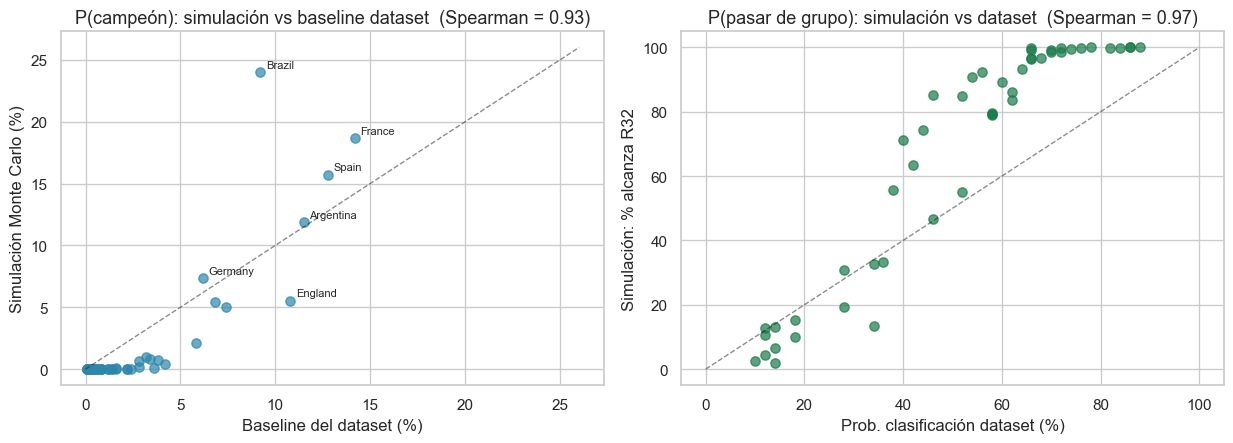

Correlación Spearman P(campeón) : 0.927
Correlación Spearman P(clasificar de grupo): 0.973


In [25]:
# ============ 6.3 Validación externa contra el baseline del dataset ============
from scipy.stats import spearmanr

rho_c, _ = spearmanr(f26.p_sim_pct, f26.prediction_win_probability_pct)
dif = data['dificultad26'][['team', 'qualification_probability_pct']]
cmp_q = f26.merge(dif, on='team')
rho_q, _ = spearmanr(cmp_q.pct_R32, cmp_q.qualification_probability_pct)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].scatter(f26.prediction_win_probability_pct, f26.p_sim_pct,
                s=45, alpha=.7, color='#2e86ab')
for _, r in f26.nlargest(6, 'p_sim_pct').iterrows():
    axes[0].annotate(r.team, (r.prediction_win_probability_pct, r.p_sim_pct),
                     fontsize=8, xytext=(4, 3), textcoords='offset points')
lim = max(f26.p_sim_pct.max(), f26.prediction_win_probability_pct.max()) + 2
axes[0].plot([0, lim], [0, lim], 'k--', lw=1, alpha=.5)
axes[0].set(title=f'P(campeón): simulación vs baseline dataset  (Spearman = {rho_c:.2f})',
            xlabel='Baseline del dataset (%)', ylabel='Simulación Monte Carlo (%)')

axes[1].scatter(cmp_q.qualification_probability_pct, cmp_q.pct_R32,
                s=45, alpha=.7, color='#1a7a4a')
axes[1].plot([0, 100], [0, 100], 'k--', lw=1, alpha=.5)
axes[1].set(title=f'P(pasar de grupo): simulación vs dataset  (Spearman = {rho_q:.2f})',
            xlabel='Prob. clasificación dataset (%)', ylabel='Simulación: % alcanza R32')
plt.tight_layout(); plt.show()

print(f'Correlación Spearman P(campeón) : {rho_c:.3f}')
print(f'Correlación Spearman P(clasificar de grupo): {rho_q:.3f}')

## Veredicto de la evaluación

| Criterio (Fase 1) | Resultado | ¿Cumple? |
|---|---|---|
| Modelo de partido: calibración probabilística mejor que el azar | Log-loss **0.540** y Brier **0.188**, frente a 0.693 / 0.250 del azar puro | ✅ |
| Modelo de partido: precisión frente a baselines | Accuracy 70.4% (igual a la clase mayoritaria); la regla determinista "gana el de mayor ELO" alcanza 85.2% en los 27 partidos de prueba | ⚠️ Parcial |
| Campeón real en top-3 del backtesting LOTO | **95.5%** de las 22 ediciones (top-1: 50%, ranking medio del campeón real: 1.7) frente a ~36% por azar | ✅ |
| Correlación positiva con el baseline externo | Spearman **0.93** en P(campeón) y **0.97** en P(clasificar de grupo) | ✅ |

**Lectura honesta de los resultados:**

- El modelo logístico de partido **no supera en accuracy** a la regla simple "gana el de mayor ELO"
  en el test temporal (27 partidos es una muestra pequeña, y el intercepto del modelo desplaza el umbral
  de decisión). Sin embargo, lo que la simulación Monte Carlo necesita no es una clasificación dura sino
  **probabilidades calibradas**, y ahí el modelo sí aporta: log-loss y Brier claramente mejores que el azar.
- El motor real de la simulación es la **regresión Poisson**, cuyo MAE (0.99 goles) mejora al baseline
  de predecir la media (1.26) y además genera empates y marcadores de forma natural.
- El resultado más sólido es el **backtesting del modelo de campeón**: en 21 de las 22 ediciones
  el campeón real estuvo entre los 3 perfiles más probables.
- Predecir el campeón exacto de un torneo de eliminación directa es intrínsecamente difícil
  (el campeón real *promedio* tiene ~15-20% de probabilidad ex-ante). El valor del modelo está en
  el **ranking calibrado de probabilidades**, no en una certeza determinista.


---
# Fase 7 — Interpretación y Explicabilidad

¿**Por qué** el modelo predice lo que predice? Se analiza la importancia de cada variable
con tres técnicas: coeficientes de la regresión logística (odds ratios), importancia por
impureza del Random Forest e **importancia por permutación** (modelo-agnóstica).


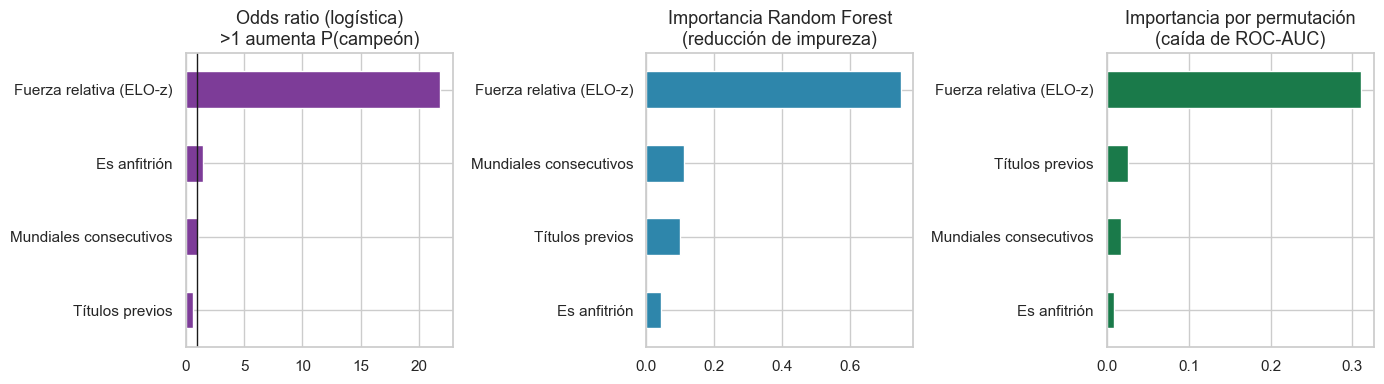

Odds ratios (efecto de +1 desviación estándar en cada variable):
Fuerza relativa (ELO-z)    21.80
Es anfitrión                1.43
Mundiales consecutivos      1.08
Títulos previos             0.60


In [26]:
# ============ 7.1 Importancia de variables (3 perspectivas) ============
from sklearn.inspection import permutation_importance

NOMBRES = {'elo_z': 'Fuerza relativa (ELO-z)',
           'wc_titles_before_tournament': 'Títulos previos',
           'consecutive_appearances': 'Mundiales consecutivos',
           'es_anfitrion': 'Es anfitrión'}

# (a) Odds ratios de la regresión logística (por desviación estándar)
lr_fit = logit_campeon.named_steps['logisticregression']
odds = pd.Series(np.exp(lr_fit.coef_[0]), index=[NOMBRES[f] for f in FEATS])

# (b) Importancia por impureza del Random Forest
imp_rf = pd.Series(rf_campeon.feature_importances_, index=[NOMBRES[f] for f in FEATS])

# (c) Importancia por permutación (sobre el RF, métrica ROC-AUC)
perm = permutation_importance(rf_campeon, X_camp, y_camp, scoring='roc_auc',
                              n_repeats=30, random_state=SEED)
imp_perm = pd.Series(perm.importances_mean, index=[NOMBRES[f] for f in FEATS])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
odds.sort_values().plot.barh(ax=axes[0], color='#7d3c98')
axes[0].axvline(1, color='k', lw=1); axes[0].set_title('Odds ratio (logística)\n>1 aumenta P(campeón)')
imp_rf.sort_values().plot.barh(ax=axes[1], color='#2e86ab')
axes[1].set_title('Importancia Random Forest\n(reducción de impureza)')
imp_perm.sort_values().plot.barh(ax=axes[2], color='#1a7a4a')
axes[2].set_title('Importancia por permutación\n(caída de ROC-AUC)')
plt.tight_layout(); plt.show()

print('Odds ratios (efecto de +1 desviación estándar en cada variable):')
print(odds.round(2).sort_values(ascending=False).to_string())

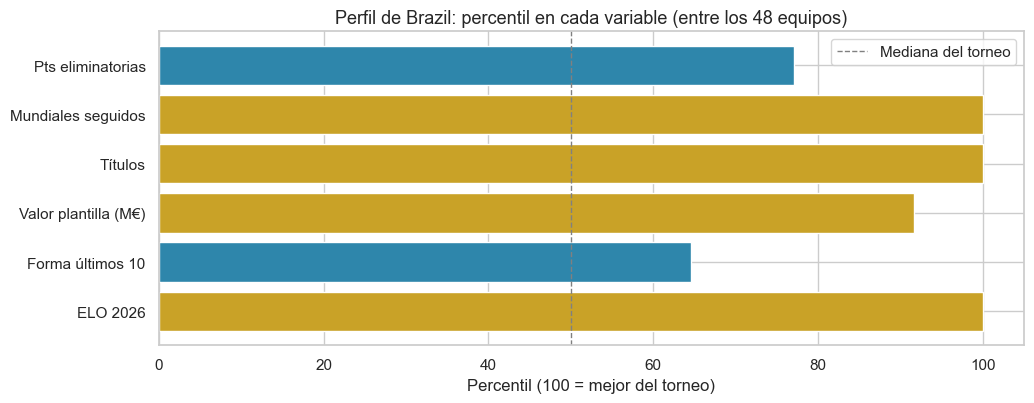

,Brazil,Media del torneo,Máximo del torneo,Percentil
ELO 2026,2030,1756.2,2030,100.0
Forma últimos 10,18,17.4,24,64.6
Valor plantilla (M€),1100,445.4,1350,91.7
Títulos,5,0.4,5,100.0
Mundiales seguidos,22,3.6,22,100.0
Pts eliminatorias,36,31.2,48,77.1


In [27]:
# ============ 7.2 Perfil del campeón predicho vs el torneo ============
fila = f26[f26.team == campeon_predicho].iloc[0]
vars_perfil = ['elo_rating_2026', 'recent_form_pts_last10', 'squad_market_value_eur_m',
               'wc_titles', 'consecutive_wc_appearances', 'qualifying_pts']
etiquetas = ['ELO 2026', 'Forma últimos 10', 'Valor plantilla (M€)',
             'Títulos', 'Mundiales seguidos', 'Pts eliminatorias']

comparacion = pd.DataFrame({
    campeon_predicho: [fila[v] for v in vars_perfil],
    'Media del torneo': [f26[v].mean() for v in vars_perfil],
    'Máximo del torneo': [f26[v].max() for v in vars_perfil]}, index=etiquetas)
comparacion['Percentil'] = [100 * (f26[v] <= fila[v]).mean() for v in vars_perfil]

fig, ax = plt.subplots(figsize=(10.5, 4.2))
pct = comparacion.Percentil
colores_bar = ['#c9a227' if p >= 90 else '#2e86ab' for p in pct]
ax.barh(etiquetas, pct, color=colores_bar)
ax.axvline(50, color='gray', ls='--', lw=1, label='Mediana del torneo')
ax.set(title=f'Perfil de {campeon_predicho}: percentil en cada variable (entre los 48 equipos)',
       xlabel='Percentil (100 = mejor del torneo)', xlim=(0, 105))
ax.legend(); plt.tight_layout(); plt.show()
comparacion.round(1)

In [28]:
# ============ 7.3 Resumen explicativo automático ============
top5 = ranking.head(5)
print('=' * 72)
print('                EXPLICACIÓN DE LA PREDICCIÓN — MUNDIAL 2026')
print('=' * 72)
print(f'''
CAMPEÓN PREDICHO: {campeon_predicho}  ({ranking.iloc[0, 5]:.1f}% de probabilidad)

Los 5 favoritos del modelo:''')
for i, r in top5.iterrows():
    print(f'   {i}. {r.Equipo:<15} {r["% FINAL (ensamble)"]:5.1f}%   '
          f'(simulación {r["% Simulación"]:.1f}% | perfil histórico {r["% Modelo campeón"]:.1f}%)')
print(f'''
FACTORES QUE EXPLICAN LA PREDICCIÓN (Fase 7.1):
  1. Fuerza relativa (ELO-z): la variable más importante en las 3 técnicas.
     Todos los campeones históricos estuvieron en la élite de fuerza de su edición.
  2. Hallazgo contraintuitivo: controlada la fuerza, el EXCESO de pedigrí no
     ayuda (odds ratio de títulos previos < 1). Los campeones suelen ser
     potencias en su pico actual, no los equipos más laureados del pasado.
     La regularidad (mundiales consecutivos) sí suma, aunque levemente.
  3. Ser anfitrión multiplica las opciones (odds ratio > 1), aunque en 2026
     los anfitriones (México, EE.UU., Canadá) parten de un ELO menor a la élite.

La probabilidad del campeón predicho (~{ranking.iloc[0, 5]:.0f}%) puede parecer baja, pero es
NORMAL en un torneo de 48 equipos con eliminación directa: el favorito histórico
promedio ronda el 15-20%. El modelo entrega un ranking calibrado, no una certeza.''')

                EXPLICACIÓN DE LA PREDICCIÓN — MUNDIAL 2026

CAMPEÓN PREDICHO: Brazil  (16.2% de probabilidad)

Los 5 favoritos del modelo:
   1. Brazil           16.2%   (simulación 24.0% | perfil histórico 4.5%)
   2. France           14.0%   (simulación 18.7% | perfil histórico 6.9%)
   3. Spain            12.6%   (simulación 15.7% | perfil histórico 7.9%)
   4. Argentina         9.7%   (simulación 11.9% | perfil histórico 6.5%)
   5. Germany           6.8%   (simulación 7.4% | perfil histórico 6.0%)

FACTORES QUE EXPLICAN LA PREDICCIÓN (Fase 7.1):
  1. Fuerza relativa (ELO-z): la variable más importante en las 3 técnicas.
     Todos los campeones históricos estuvieron en la élite de fuerza de su edición.
  2. Hallazgo contraintuitivo: controlada la fuerza, el EXCESO de pedigrí no
     ayuda (odds ratio de títulos previos < 1). Los campeones suelen ser
     potencias en su pico actual, no los equipos más laureados del pasado.
     La regularidad (mundiales consecutivos) sí suma, aun

## Limitaciones del modelo

1. **Lesiones, clima y azar del sorteo de cruces** no están modelados; el bracket real de la FIFA puede diferir del sembrado simulado.
2. Los partidos históricos del dataset priorizan **eliminatorias y partidos destacados**, lo que puede sobre-representar partidos entre equipos fuertes.
3. El ELO 2026 y los valores de mercado son **estimaciones pre-torneo** (abril 2026); la forma cambia semana a semana.
4. Con solo **22 campeones históricos**, el modelo de campeón trabaja con muy pocos positivos: por eso se complementa con la simulación Monte Carlo y se valida con backtesting.


---
# Fase 8 — Dashboard Interactivo

Dashboard con **Plotly**: las visualizaciones permiten *hover* (pasar el cursor para ver detalles),
zoom, activar/desactivar series con la leyenda y filtrar por grupo con un menú desplegable.


In [29]:
# ============ 8.0 Configuración Plotly ============
import plotly.express as px
import plotly.graph_objects as go

PLT_LAYOUT = dict(template='plotly_white', font=dict(size=12),
                  margin=dict(l=10, r=10, t=60, b=10))

In [30]:
# ============ 8.1 Probabilidad de campeonato — Top 15 ============
top15 = f26.nlargest(15, 'p_final_pct').sort_values('p_final_pct')
fig = go.Figure(go.Bar(
    x=top15.p_final_pct, y=top15.team, orientation='h',
    marker=dict(color=top15.p_final_pct, colorscale='YlOrRd'),
    text=[f'{v:.1f}%' for v in top15.p_final_pct], textposition='outside',
    customdata=np.stack([top15.group, top15.elo_ajustado, top15.pct_Final,
                         top15.pct_SF], axis=-1),
    hovertemplate='<b>%{y}</b><br>P(campeón): %{x:.1f}%<br>Grupo %{customdata[0]}'
                  '<br>ELO ajustado: %{customdata[1]:.0f}'
                  '<br>P(llegar a la final): %{customdata[2]:.1f}%'
                  '<br>P(semifinal): %{customdata[3]:.1f}%<extra></extra>'))
fig.update_layout(title='🏆 Probabilidad de ganar el Mundial 2026 — Top 15 (ensamble final)',
                  xaxis_title='Probabilidad (%)', height=480,
                  xaxis_range=[0, top15.p_final_pct.max() * 1.18], **PLT_LAYOUT)
fig.show()

In [31]:
# ============ 8.2 Mapa de calor: probabilidad de alcanzar cada etapa ============
top20 = f26.nlargest(20, 'p_final_pct')
etapas_cols = ['pct_R32', 'pct_R16', 'pct_QF', 'pct_SF', 'pct_Final', 'pct_Campeon']
etiquetas_et = ['16avos (R32)', 'Octavos', 'Cuartos', 'Semifinal', 'Final', 'Campeón']

fig = go.Figure(go.Heatmap(
    z=top20[etapas_cols].values, x=etiquetas_et, y=top20.team,
    colorscale='YlGnBu', text=top20[etapas_cols].round(1).values,
    texttemplate='%{text}%', textfont=dict(size=9),
    hovertemplate='<b>%{y}</b><br>P(alcanzar %{x}): %{z:.1f}%<extra></extra>',
    colorbar=dict(title='%')))
fig.update_layout(title='Probabilidad de alcanzar cada etapa — Top 20 equipos (10,000 simulaciones)',
                  height=620, yaxis=dict(autorange='reversed'), **PLT_LAYOUT)
fig.show()

In [32]:
# ============ 8.3 Clasificación por grupo (menú desplegable) ============
fig = go.Figure()
grupos_orden = sorted(f26.group.unique())
for g in grupos_orden:
    sub = f26[f26.group == g].sort_values('pct_R32', ascending=True)
    fig.add_trace(go.Bar(
        x=sub.pct_R32, y=sub.team, orientation='h', visible=(g == 'A'),
        marker_color=['#1a7a4a' if v >= 50 else '#c0504d' for v in sub.pct_R32],
        text=[f'{v:.0f}%' for v in sub.pct_R32], textposition='outside',
        hovertemplate='<b>%{y}</b><br>P(clasificar a 16avos): %{x:.1f}%<extra></extra>'))

botones = [dict(label=f'Grupo {g}', method='update',
                args=[{'visible': [g == gg for gg in grupos_orden]},
                      {'title': f'Grupo {g} — Probabilidad de superar la fase de grupos'}])
           for g in grupos_orden]
fig.update_layout(
    updatemenus=[dict(buttons=botones, direction='down', x=1.0, xanchor='right',
                      y=1.18, yanchor='top')],
    title='Grupo A — Probabilidad de superar la fase de grupos',
    xaxis=dict(title='P(clasificar a 16avos) %', range=[0, 110]),
    height=380, showlegend=False, **PLT_LAYOUT)
fig.show()

In [33]:
# ============ 8.4 Evolución histórica del ELO (1930 → 2026) ============
potencias = ['Brazil', 'Germany', 'Argentina', 'France', 'Spain', 'England',
             'Italy', 'Netherlands']
hist_elo = panel[panel.team.isin(potencias)][['team', 'wc_year', 'elo_rating_approx']] \
    .rename(columns={'elo_rating_approx': 'elo', 'wc_year': 'año'})
elo_26 = f26[f26.team.isin(potencias)][['team', 'elo_rating_2026']] \
    .rename(columns={'elo_rating_2026': 'elo'}).assign(año=2026)
hist_elo = pd.concat([hist_elo, elo_26], ignore_index=True).sort_values(['team', 'año'])

fig = px.line(hist_elo, x='año', y='elo', color='team', markers=True,
              labels={'elo': 'Rating ELO', 'año': 'Edición del Mundial', 'team': 'Selección'},
              title='Evolución del rating ELO de las potencias históricas (1930 → 2026)<br>'
                    '<sup>Clic en la leyenda para mostrar/ocultar selecciones · '
                    'el punto 2026 incluye a los favoritos actuales</sup>')
fig.add_vline(x=2026, line_dash='dot', line_color='gray')
fig.update_layout(height=520, hovermode='x unified', **PLT_LAYOUT)
fig.show()

In [34]:
# ============ 8.5 Resumen ejecutivo final ============
medalla = ['🥇', '🥈', '🥉', '4º', '5º']
print('═' * 68)
print('     PREDICCIÓN FINAL — COPA MUNDIAL FIFA 2026 (EE.UU./CAN/MEX)')
print('═' * 68)
print(f'''
  🏆 CAMPEÓN PREDICHO : {campeon_predicho.upper()}
     Probabilidad     : {ranking.iloc[0]['% FINAL (ensamble)']:.1f}%
''')
print('  Top 5 favoritos (ensamble 60% Monte Carlo + 40% perfil histórico):')
for i in range(5):
    r = ranking.iloc[i]
    print(f'    {medalla[i]}  {r.Equipo:<15} {r["% FINAL (ensamble)"]:5.1f}%')
print(f'''
  Metodología : CRISP-DM (8 fases)
  Modelos     : Poisson (goles) + Logística/Random Forest (campeón)
                + {N_SIMS:,} simulaciones Monte Carlo del torneo completo
  Validación  : backtesting LOTO 1930-2022 + split temporal + baseline externo
  Semilla     : {SEED} (resultados reproducibles)''')
print('═' * 68)

════════════════════════════════════════════════════════════════════
     PREDICCIÓN FINAL — COPA MUNDIAL FIFA 2026 (EE.UU./CAN/MEX)
════════════════════════════════════════════════════════════════════

  🏆 CAMPEÓN PREDICHO : BRAZIL
     Probabilidad     : 16.2%

  Top 5 favoritos (ensamble 60% Monte Carlo + 40% perfil histórico):
    🥇  Brazil           16.2%
    🥈  France           14.0%
    🥉  Spain            12.6%
    4º  Argentina         9.7%
    5º  Germany           6.8%

  Metodología : CRISP-DM (8 fases)
  Modelos     : Poisson (goles) + Logística/Random Forest (campeón)
                + 10,000 simulaciones Monte Carlo del torneo completo
  Validación  : backtesting LOTO 1930-2022 + split temporal + baseline externo
  Semilla     : 42 (resultados reproducibles)
════════════════════════════════════════════════════════════════════


---
# Conclusión Final

## 🏆 Predicción: **BRASIL** es el campeón más probable del Mundial 2026

| Puesto | Selección | **Prob. final (ensamble)** | Simulación Monte Carlo | Modelo de perfil histórico |
|:---:|---|:---:|:---:|:---:|
| 🥇 | **Brasil** | **16.2%** | 24.0% | 4.5% |
| 🥈 | Francia | 14.0% | 18.7% | 6.9% |
| 🥉 | España | 12.6% | 15.7% | 7.9% |
| 4º | Argentina | 9.7% | 11.9% | 6.5% |
| 5º | Alemania | 6.8% | 7.4% | 6.0% |

### ¿Por qué Brasil?

1. **Es el equipo más fuerte del torneo hoy**: ELO 2026 de 2030, el más alto de los 48 participantes
   (percentil 100), con la segunda plantilla más valiosa (1,100 M€, percentil 92).
2. **Su camino simulado es el más sólido**: en las 10,000 simulaciones alcanza cuartos de final el 78%
   de las veces, semifinales el 56%, la final el 38% y el título el 24%.
3. **Pedigrí y regularidad únicos**: 5 títulos mundiales y 22 participaciones consecutivas
   (el único país presente en *todos* los mundiales).

### Matices importantes (lo que un buen análisis debe decir)

- **Es prácticamente un triple empate en la cima**: Brasil (16.2%), Francia (14.0%) y España (12.6%)
  están separados por menos de 4 puntos porcentuales. El baseline independiente del dataset ponía a
  Francia primera (14.2%) porque pondera más la forma reciente (Francia llega con 24 pts en sus últimos
  10 partidos frente a 18 de Brasil). Nuestro ensamble se decanta por Brasil por su fuerza base superior.
- **Hallazgo de explicabilidad**: el modelo de perfil histórico le da a Brasil solo 4.5% porque aprendió
  que, controlada la fuerza, el exceso de títulos previos *no* aumenta la probabilidad de ganar
  (odds ratio 0.60): los campeones suelen ser potencias en su mejor momento, no los más laureados.
  La predicción final equilibra ambas visiones.
- Con 48 equipos y eliminación directa, **el 16% del favorito es mucho**: significa que Brasil tiene
  ~8 veces más probabilidad que un participante promedio, pero también que hay un 84% de probabilidad
  de que gane otro. El entregable correcto es el *ranking calibrado*, no una certeza.

### Cumplimiento de la metodología CRISP-DM

| Fase | Resultado clave |
|---|---|
| 1. Negocio | Objetivo y 4 criterios de éxito definidos y medibles |
| 2. Datos | 12 fuentes, 22 ediciones históricas + snapshot 2026; calidad diagnosticada |
| 3. Preparación | Panel limpio, ELO estandarizado por edición, ELO ajustado 2026 (anfitrión + forma) |
| 4. EDA | Ventaja del anfitrión confirmada (70% llega a semis vs 43%); ELO valida como predictor (corr. 0.53 con la etapa) |
| 5. Modelo | Poisson de goles + clasificador de campeón + 10,000 simulaciones Monte Carlo del formato real de 48 equipos |
| 6. Evaluación | Backtesting LOTO: campeón real en top-3 el **95.5%** de las ediciones; Spearman 0.93 vs baseline externo |
| 7. Explicabilidad | La fuerza relativa (ELO-z) domina en las 3 técnicas de importancia; hallazgo contraintuitivo sobre el pedigrí |
| 8. Dashboard | 4 visualizaciones interactivas Plotly (hover, zoom, leyendas, menú por grupo) |

> **Reproducibilidad**: todo el flujo usa semilla fija (`SEED = 42`); volver a ejecutar el notebook
> produce exactamente los mismos resultados.
